# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime

# Load the Dataset

In [2]:
df = pd.read_csv('output/latency_analysis.csv')
print(df.head())

   action_count  duration      end_time                         model  \
0           NaN  2.569493  1.764318e+09                           NaN   
1           NaN  4.686441  1.764318e+09  models/gemini-2.5-flash-lite   
2           NaN  4.695616  1.764318e+09                           NaN   
3           NaN  5.428930  1.764318e+09                           NaN   
4           1.0  5.434189  1.764318e+09                           NaN   

              name                                run_id  run_timestamp  \
0        get_state  a139b1d8-0884-406c-8c28-18915f7b9633   1.764318e+09   
1         llm_call  a139b1d8-0884-406c-8c28-18915f7b9633   1.764318e+09   
2  get_next_action  a139b1d8-0884-406c-8c28-18915f7b9633   1.764318e+09   
3   search_youtube  a139b1d8-0884-406c-8c28-18915f7b9633   1.764318e+09   
4        multi_act  a139b1d8-0884-406c-8c28-18915f7b9633   1.764318e+09   

     start_time  step_number                task task_id  
0  1.764318e+09            1  play ruhuna anthem   

# Data Cleaning and Preprocessing

In [3]:
# Convert timestamps
df['start_time'] = pd.to_datetime(df['start_time'], unit='s')
df['end_time'] = pd.to_datetime(df['end_time'], unit='s')
df['run_timestamp'] = pd.to_datetime(df['run_timestamp'], unit='s')

# Handle missing values
df.fillna({'action_count': 0, 'model': 'unknown', 'task': 'unknown'}, inplace=True)

# Convert duration to float if needed
df['duration'] = df['duration'].astype(float)

print(df.dtypes)

action_count            float64
duration                float64
end_time         datetime64[ns]
model                    object
name                     object
run_id                   object
run_timestamp    datetime64[ns]
start_time       datetime64[ns]
step_number               int64
task                     object
task_id                  object
dtype: object


# Basic Data Exploration

In [4]:
print(df.shape)
print(df.columns)
print('Unique names:', df['name'].unique())
print('Unique tasks:', df['task'].unique())
print('Unique models:', df['model'].unique())
print('Number of unique run_ids:', df['run_id'].nunique())

(62, 11)
Index(['action_count', 'duration', 'end_time', 'model', 'name', 'run_id',
       'run_timestamp', 'start_time', 'step_number', 'task', 'task_id'],
      dtype='object')
Unique names: ['get_state' 'llm_call' 'get_next_action' 'search_youtube' 'multi_act'
 'step' 'click_element' 'done' 'go_to_url' 'search_google' 'go_back'
 'switch_tab' 'extract_content']
Unique tasks: ['play ruhuna anthem' 'unknown' 'open google' 'open ruhuna eng lms']
Unique models: ['unknown' 'models/gemini-2.5-flash-lite']
Number of unique run_ids: 3


# Statistical Summary

In [5]:
print(df.describe())
print(df.groupby('name')['duration'].describe())

       action_count   duration                       end_time  \
count      62.00000  62.000000                             62   
mean        0.16129   6.362593  2025-11-28 08:31:54.033699584   
min         0.00000   0.000000  2025-11-28 08:25:28.163094282   
25%         0.00000   2.679646  2025-11-28 08:26:46.701392384   
50%         0.00000   4.602370  2025-11-28 08:35:42.364825600   
75%         0.00000   6.808931  2025-11-28 08:36:30.460537344   
max         2.00000  34.931352  2025-11-28 08:36:52.184478283   
std         0.41265   7.061132                            NaN   

                       run_timestamp                     start_time  \
count                             62                             62   
mean   2025-11-28 08:31:07.428537088  2025-11-28 08:31:47.671107072   
min    2025-11-28 08:25:25.490869284  2025-11-28 08:25:25.593601704   
25%    2025-11-28 08:25:25.490869248  2025-11-28 08:26:42.525670144   
50%    2025-11-28 08:35:27.676736512  2025-11-28 08:35:34.6

# Distribution Analysis

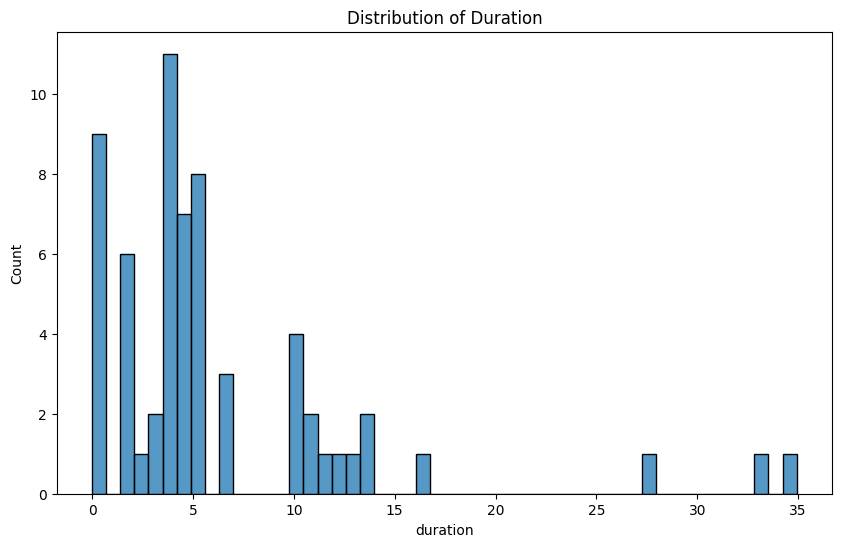

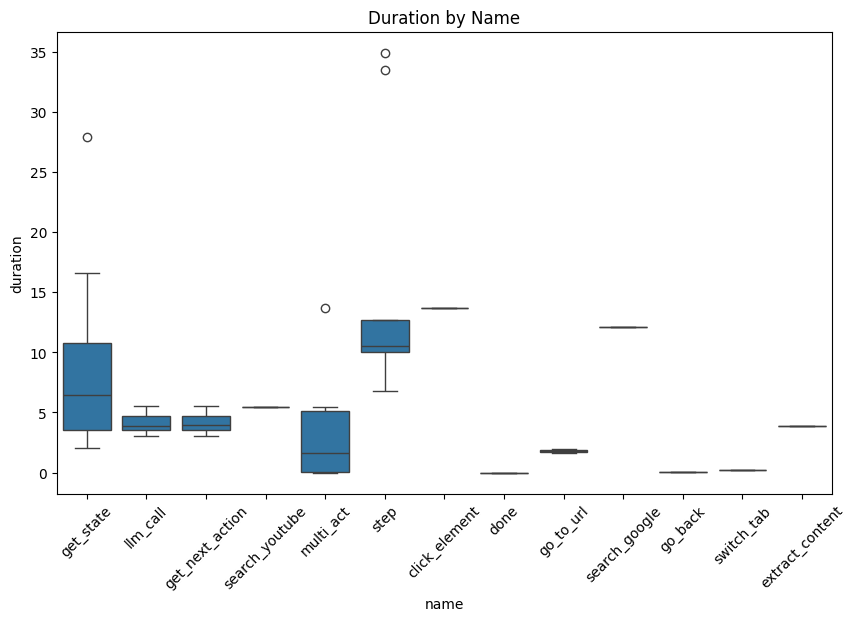

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df['duration'], bins=50)
plt.title('Distribution of Duration')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='name', y='duration', data=df)
plt.title('Duration by Name')
plt.xticks(rotation=45)
plt.show()

# Time Series Analysis

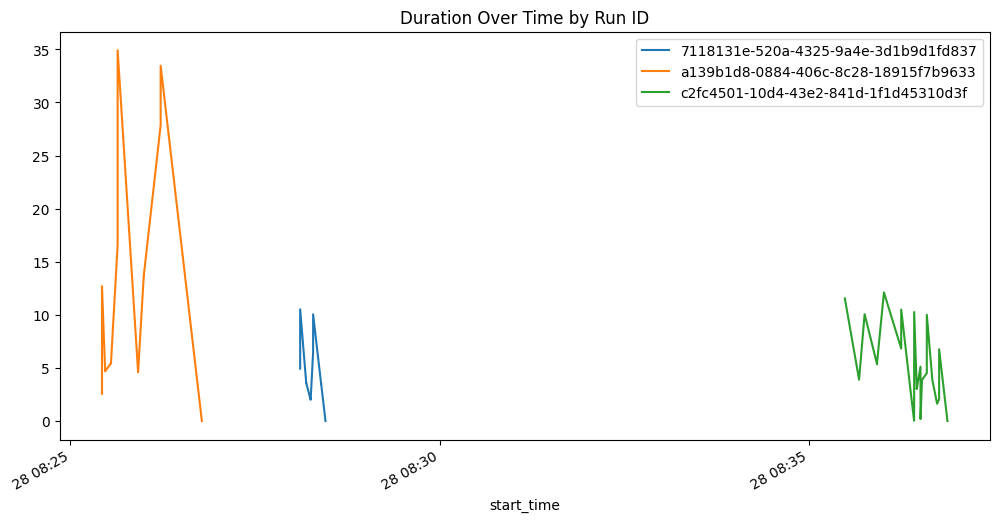

In [7]:
df_ts = df.set_index('start_time').sort_index()
plt.figure(figsize=(12,6))
for run_id, group in df_ts.groupby('run_id'):
    group['duration'].plot(label=run_id)
plt.title('Duration Over Time by Run ID')
plt.legend()
plt.show()

# Correlation Analysis

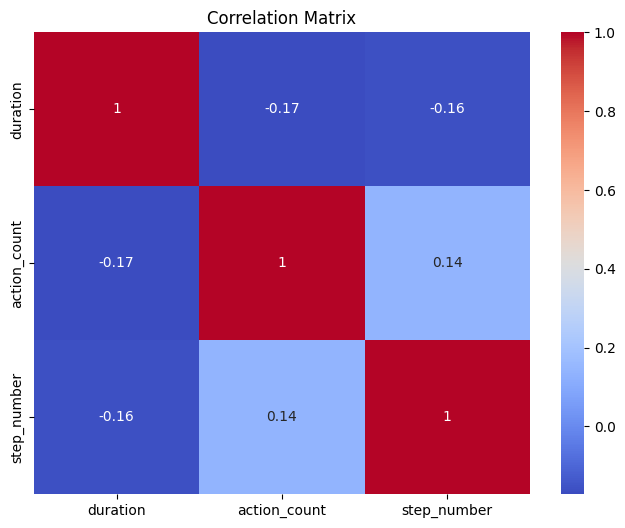

In [8]:
numeric_cols = ['duration', 'action_count', 'step_number']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Visualization of Key Metrics

In [9]:
avg_duration_task = df.groupby('task')['duration'].mean().reset_index()
fig = px.bar(avg_duration_task, x='task', y='duration', title='Average Duration by Task')
fig.show()

run_summary = df.groupby('run_id').agg({'duration': 'sum', 'action_count': 'sum'}).reset_index()
fig = px.scatter(run_summary, x='action_count', y='duration', title='Total Duration vs Action Count by Run')
fig.show()

# Action vs Duration Analysis

In [10]:
# Average Duration per Action
avg_duration_action = df.groupby('name')['duration'].mean().reset_index().sort_values('duration', ascending=False)
fig = px.bar(avg_duration_action, x='name', y='duration', title='Average Duration by Action')
fig.show()

In [11]:
# Duration Distribution per Action
fig = px.box(df, x='name', y='duration', title='Duration Distribution by Action')
fig.show()

In [12]:
# Total Duration per Action
total_duration_action = df.groupby('name')['duration'].sum().reset_index().sort_values('duration', ascending=False)
fig = px.bar(total_duration_action, x='name', y='duration', title='Total Duration by Action')
fig.show()

In [13]:
# Action Frequency
action_counts = df['name'].value_counts().reset_index()
action_counts.columns = ['name', 'count']
fig = px.bar(action_counts, x='name', y='count', title='Action Frequency')
fig.show()